# Report Figures — Task 1 (Streamflow) and Task 2 (Building Damage)

This notebook generates the figures that go into the 5-page report and
the 15-minute presentation. It reads the artifacts produced by:

- `task1_runoff/scripts/run_comparison.py` (Task 1 sweep)
- `task2_buildings/scripts/run_comparison.py` (Task 2 sweep)
  *or* individual `train_baseline.py` runs.


## Setup

In [13]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Output directory for saved figures
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------------
# Locate run directories. The notebook expects to be in
#   <repo_root>/notebooks/  (alongside task1_runoff/ and task2_buildings/)
# OR inside one of the task folders.
# ------------------------------------------------------------------
HERE = Path.cwd()
def find_root():
    for cand in [HERE, HERE.parent, HERE.parent.parent]:
        if (cand / "task1_runoff").exists() and (cand / "task2_buildings").exists():
            return cand
    return HERE.parent.parent
ROOT = find_root()
print(f"Repository root: {ROOT}")

T1_RUNS = ROOT / "task1_runoff" / "runs"
T2_RUNS = ROOT / "task2_buildings" / "runs"
print(f"Task 1 runs/ exists: {T1_RUNS.exists()}")
print(f"Task 2 runs/ exists: {T2_RUNS.exists()}")

Repository root: /Users/michaelray/Documents/School/ASU/Spring 2026/AI/Final/AI-Final-Project-Group-TPR-DS-Project-GroupTPR-
Task 1 runs/ exists: True
Task 2 runs/ exists: True


## Helpers — find latest sweep / run

The run-comparison scripts dump artifacts into a directory like
`runs/comparison_<timestamp>/individual_runs/<model>_lead<h>_<ts>/`.
These helpers locate the latest sweep and pull the per-run files.

In [14]:
def latest_dir(parent: Path, prefix: str = ""):
    """Return the most recently modified subdirectory matching prefix."""
    if not parent.exists():
        return None
    candidates = [d for d in parent.iterdir()
                  if d.is_dir() and d.name.startswith(prefix)]
    if not candidates:
        return None
    return max(candidates, key=lambda d: d.stat().st_mtime)


def find_t1_runs():
    """Return dict keyed (gauge, lead, model) → Path of individual run dir.

    Looks first inside the latest comparison_ sweep, then falls back to
    direct runs/<model>_lead<h>_* directories at the top level.
    """
    out = {}
    sweep = latest_dir(T1_RUNS, "comparison_")
    if sweep is not None:
        ind_dir = sweep / "individual_runs"
        if ind_dir.exists():
            for d in ind_dir.iterdir():
                if not d.is_dir():
                    continue
                # Names look like: lstm_lead6_1776... or transformer_lead18_...
                # We need gauge ID too, which is in summary.json
                summary_path = d / "summary.json"
                if summary_path.exists():
                    try:
                        with open(summary_path) as f:
                            s = json.load(f)
                        cfg = s.get("config", {})
                        parquet = cfg.get("parquet", "")
                        # parquet path looks like .../gauge_21609641.parquet
                        gauge = Path(parquet).stem.replace("gauge_", "")
                        lead = cfg.get("target_lead")
                        model = cfg.get("model")
                        out[(gauge, lead, model)] = d
                    except Exception:
                        pass
    return out


def find_t2_runs():
    """Return dict model → latest run dir for Task 2."""
    out = {}
    sweep = latest_dir(T2_RUNS, "comparison_")
    if sweep is not None:
        ind_dir = sweep / "individual_runs"
        if ind_dir.exists():
            for d in ind_dir.iterdir():
                if not d.is_dir():
                    continue
                # Name like resnet50_177... or efficientnet_177... or vit_177...
                model = d.name.split("_")[0]
                if model in ("resnet50", "efficientnet", "vit"):
                    out[model] = d
    # Fallback: find latest <model>_<ts>/ in T2_RUNS top-level
    if not out and T2_RUNS.exists():
        for d in T2_RUNS.iterdir():
            if not d.is_dir():
                continue
            for model in ("resnet50", "efficientnet", "vit"):
                if d.name.startswith(model + "_"):
                    if model not in out or d.stat().st_mtime > out[model].stat().st_mtime:
                        out[model] = d
    return out


t1_runs = find_t1_runs()
t2_runs = find_t2_runs()
print(f"Found {len(t1_runs)} Task 1 runs.")
if t1_runs:
    seen = sorted(t1_runs.keys())
    print(f"  example keys: {seen[:3]} ...")
print(f"Found {len(t2_runs)} Task 2 runs: {sorted(t2_runs.keys())}")

Found 24 Task 1 runs.
  example keys: [('20380357', 1, 'gru'), ('20380357', 1, 'lstm'), ('20380357', 1, 'transformer')] ...
Found 3 Task 2 runs: ['efficientnet', 'resnet50', 'vit']


---
# Task 1 figures

## Figure 1 — Training curves

Per-epoch train and val loss for each architecture on gauge 21609641 at
lead 6h. Diagnoses overfitting and shows the early-stopping trigger.

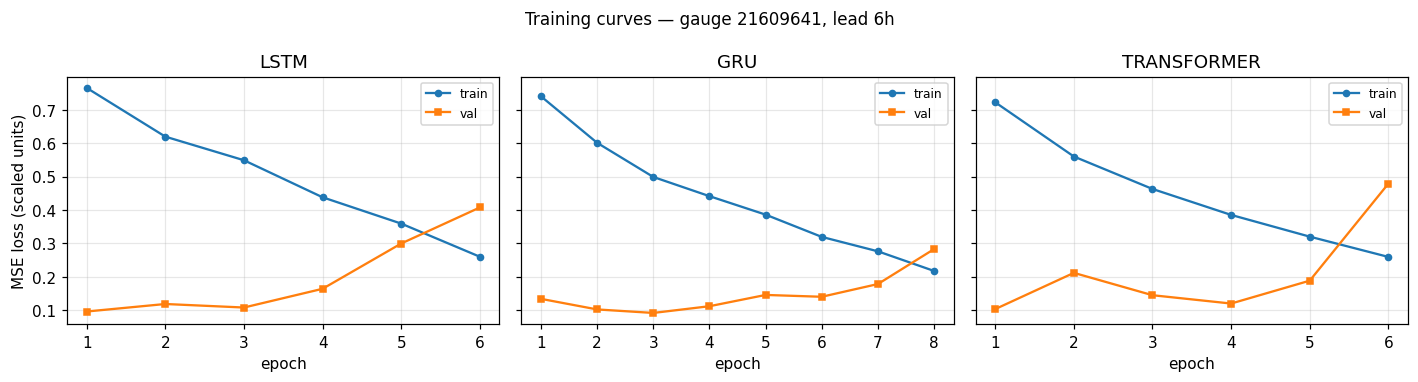

  → figures/task1_training_curves.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), sharey=True)
GAUGE_FOR_CURVES = "21609641"
LEAD_FOR_CURVES = 6

for ax, model in zip(axes, ["lstm", "gru", "transformer"]):
    key = (GAUGE_FOR_CURVES, LEAD_FOR_CURVES, model)
    run = t1_runs.get(key)
    if run is None:
        ax.text(0.5, 0.5, f"no run found\nfor {model}",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(model.upper())
        continue
    h = pd.read_csv(run / "history.csv")
    ax.plot(h["epoch"], h["train_loss"], "-o", label="train", markersize=4)
    ax.plot(h["epoch"], h["val_loss"], "-s", label="val", markersize=4)
    ax.set_xlabel("epoch")
    ax.set_title(f"{model.upper()}")
    ax.legend(fontsize=8)

axes[0].set_ylabel("MSE loss (scaled units)")
fig.suptitle(f"Training curves — gauge {GAUGE_FOR_CURVES}, lead {LEAD_FOR_CURVES}h",
             fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "task1_training_curves.png", bbox_inches="tight")
plt.show()
print("  → figures/task1_training_curves.png")

## Figure 2 — Hydrograph slice (test set)

Observed flow vs raw NWM vs DL-corrected forecast over a representative
two-week window in the test period. Picks a slice that includes a
flow event so the model's correction behavior on storms is visible.

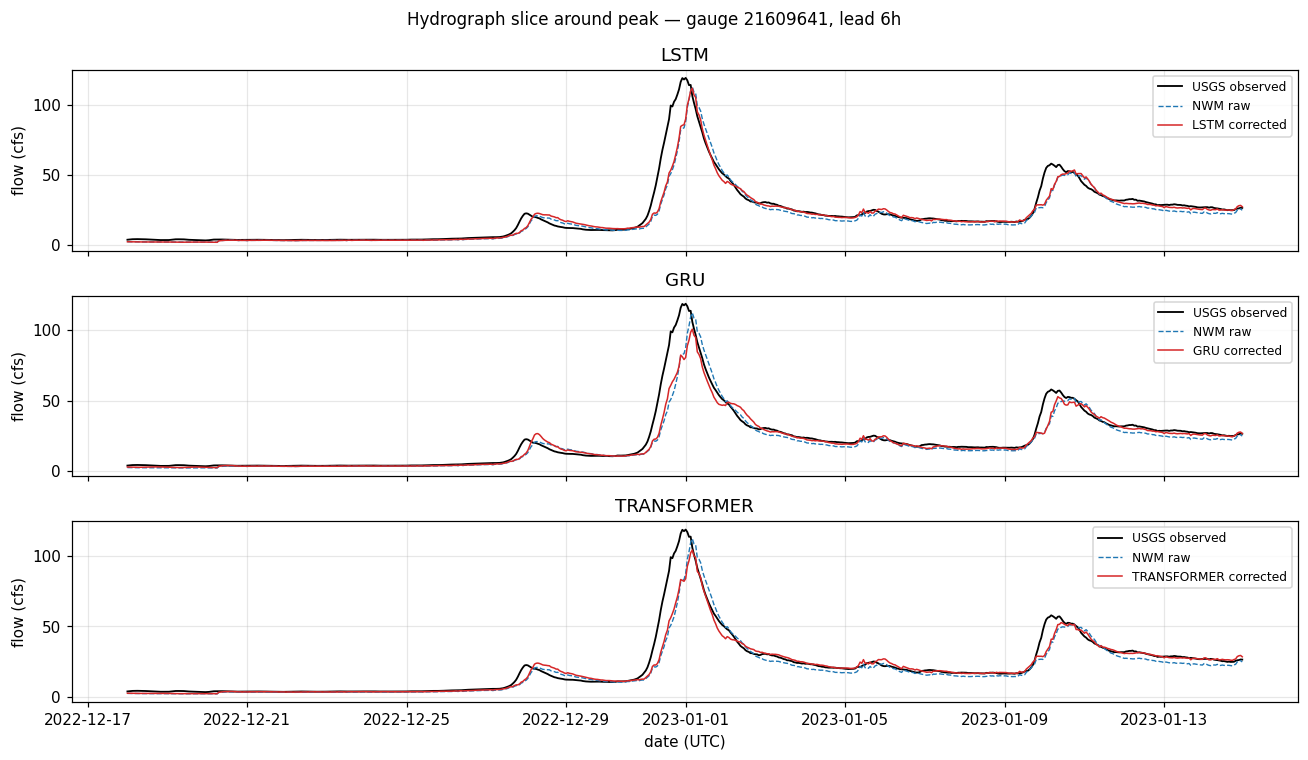

  → figures/task1_hydrograph.png


In [16]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True, sharey=True)

# Find a slice with high flow variation in the test data
GAUGE_FOR_HYDRO = "21609641"
LEAD_FOR_HYDRO = 6

# Use one model's predictions to find an interesting window
ref_run = t1_runs.get((GAUGE_FOR_HYDRO, LEAD_FOR_HYDRO, "lstm"))
if ref_run is None:
    print("Need at least the LSTM run for hydrograph. Skipping.")
else:
    ref = pd.read_csv(ref_run / "test_predictions.csv")
    ref["timestamp"] = pd.to_datetime(ref["timestamp"], utc=True)
    ref = ref.sort_values("timestamp").reset_index(drop=True)

    # Find the hour with the highest USGS observation and zoom there
    peak_idx = ref["usgs_obs"].idxmax()
    half = 14 * 24  # 14-day window centered on peak
    start = max(0, peak_idx - half)
    end = min(len(ref), peak_idx + half)

    for ax, model in zip(axes, ["lstm", "gru", "transformer"]):
        key = (GAUGE_FOR_HYDRO, LEAD_FOR_HYDRO, model)
        run = t1_runs.get(key)
        if run is None:
            ax.text(0.5, 0.5, f"no run for {model}", ha="center",
                    va="center", transform=ax.transAxes)
            ax.set_ylabel(model.upper())
            continue
        df = pd.read_csv(run / "test_predictions.csv")
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
        df = df.sort_values("timestamp").reset_index(drop=True)
        sub = df.iloc[start:end]

        ax.plot(sub["timestamp"], sub["usgs_obs"],   "k",      lw=1.2, label="USGS observed")
        ax.plot(sub["timestamp"], sub["nwm_raw"],     "C0--",   lw=0.9, label="NWM raw")
        ax.plot(sub["timestamp"], sub["nwm_corrected"], "C3",   lw=1.0,
                label=f"{model.upper()} corrected")
        ax.set_ylabel("flow (cfs)")
        ax.legend(loc="upper right", fontsize=8)
        ax.set_title(f"{model.upper()}")

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    axes[-1].set_xlabel("date (UTC)")
    fig.suptitle(f"Hydrograph slice around peak — gauge {GAUGE_FOR_HYDRO}, lead {LEAD_FOR_HYDRO}h",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "task1_hydrograph.png", bbox_inches="tight")
    plt.show()
    print("  → figures/task1_hydrograph.png")

## Figure 3 — NSE vs forecast lead time

The headline plot for the report. Shows that:

- All three DL models beat raw NWM at every lead time.
- The improvement grows with lead time (NWM degrades faster than DL).
- Different models win at different leads.

Two panels: one per gauge. The 20380357 panel uses a clipped y-axis since
NWM is so catastrophically miscalibrated that linear scaling makes the DL
results invisible.

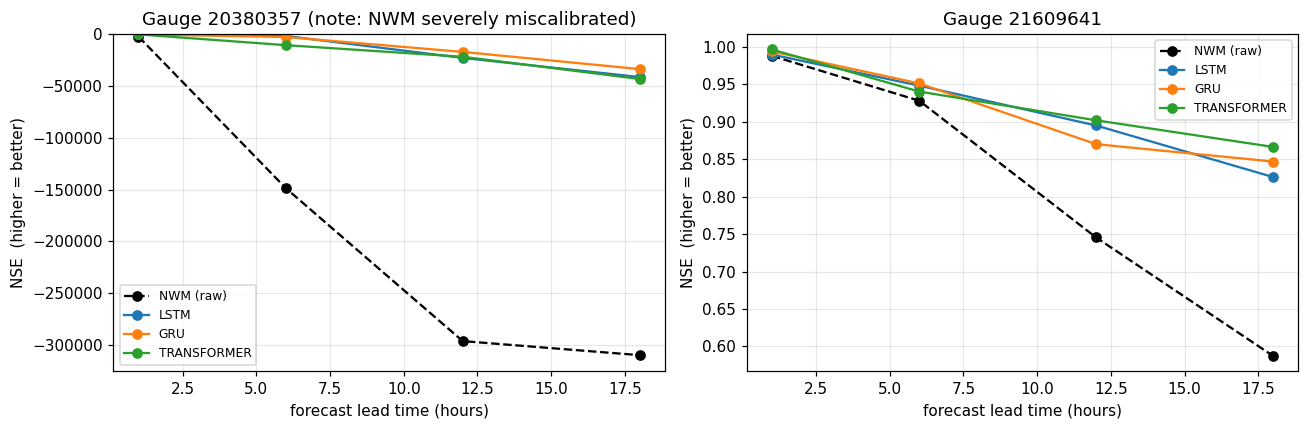

  → figures/task1_nse_vs_lead.png


In [17]:
def collect_nse_by_lead(gauge: str) -> pd.DataFrame:
    rows = []
    for (g, lead, model), run in t1_runs.items():
        if g != gauge:
            continue
        sjson = run / "summary.json"
        if not sjson.exists():
            continue
        with open(sjson) as f:
            s = json.load(f)
        rows.append({
            "lead": lead, "model": model,
            "nwm_nse": s["metrics_nwm_baseline"]["nse"],
            "dl_nse":  s["metrics_dl_corrected"]["nse"],
        })
    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values(["lead", "model"]).reset_index(drop=True)


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, gauge in zip(axes, ["20380357", "21609641"]):
    df = collect_nse_by_lead(gauge)
    if df.empty:
        ax.text(0.5, 0.5, f"no runs for gauge {gauge}",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"Gauge {gauge}")
        continue

    # NWM baseline (one value per lead, take first occurrence)
    nwm_per_lead = df.groupby("lead")["nwm_nse"].first()
    ax.plot(nwm_per_lead.index, nwm_per_lead.values, "k--o",
            lw=1.5, label="NWM (raw)")

    for model, color in zip(["lstm", "gru", "transformer"], ["C0", "C1", "C2"]):
        sub = df[df["model"] == model].sort_values("lead")
        if sub.empty:
            continue
        ax.plot(sub["lead"], sub["dl_nse"], "-o", color=color,
                lw=1.5, label=model.upper())

    ax.set_xlabel("forecast lead time (hours)")
    ax.set_ylabel("NSE  (higher = better)")
    ax.set_title(f"Gauge {gauge}")
    ax.legend(loc="best", fontsize=8)

    # For 20380357, NSE is so negative it overwhelms the plot. Clip the y-axis
    # so the relative differences are visible.
    if gauge == "20380357":
        # Clip below at the worst NWM by a margin (visualization only)
        nwm_min = nwm_per_lead.min()
        ax.set_ylim(min(nwm_min * 1.05, df["dl_nse"].min() * 1.05), 1.0)
        ax.set_title(f"Gauge {gauge} (note: NWM severely miscalibrated)")

plt.tight_layout()
plt.savefig(FIG_DIR / "task1_nse_vs_lead.png", bbox_inches="tight")
plt.show()
print("  → figures/task1_nse_vs_lead.png")

## Figure 4 — Predicted vs observed scatter

Three panels showing each model's corrected forecast (y) against the
USGS observation (x) for the entire test window of gauge 21609641 at
lead 6h. A 1:1 reference line is overlaid. Closer to the line is better.

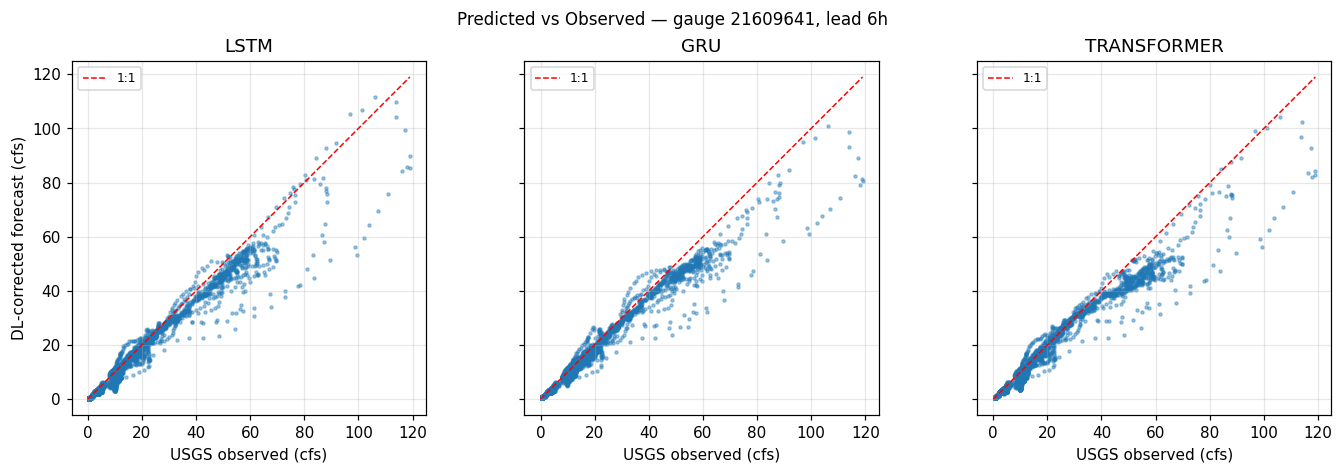

  → figures/task1_pred_vs_obs.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True)
GAUGE = "21609641"
LEAD = 6

# Get max for axis scaling
max_val = 0
for model in ["lstm", "gru", "transformer"]:
    run = t1_runs.get((GAUGE, LEAD, model))
    if run is None:
        continue
    df = pd.read_csv(run / "test_predictions.csv")
    max_val = max(max_val, df["usgs_obs"].max(), df["nwm_corrected"].max())

for ax, model in zip(axes, ["lstm", "gru", "transformer"]):
    run = t1_runs.get((GAUGE, LEAD, model))
    if run is None:
        ax.text(0.5, 0.5, f"no run for {model}", ha="center",
                va="center", transform=ax.transAxes)
        ax.set_title(model.upper())
        continue
    df = pd.read_csv(run / "test_predictions.csv")
    ax.scatter(df["usgs_obs"], df["nwm_corrected"], s=4, alpha=0.4)
    ax.plot([0, max_val], [0, max_val], "r--", lw=1, label="1:1")
    ax.set_xlabel("USGS observed (cfs)")
    ax.set_title(model.upper())
    ax.legend(fontsize=8)
    ax.set_aspect("equal")

axes[0].set_ylabel("DL-corrected forecast (cfs)")
fig.suptitle(f"Predicted vs Observed — gauge {GAUGE}, lead {LEAD}h",
             fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "task1_pred_vs_obs.png", bbox_inches="tight")
plt.show()
print("  → figures/task1_pred_vs_obs.png")

## Figure 5 — Improvement over NWM at the longest lead (18h)

Bar chart showing Δ(metric) = DL − NWM at the most operationally
challenging lead time. This is the strongest "value of the project"
visualization for the presentation.

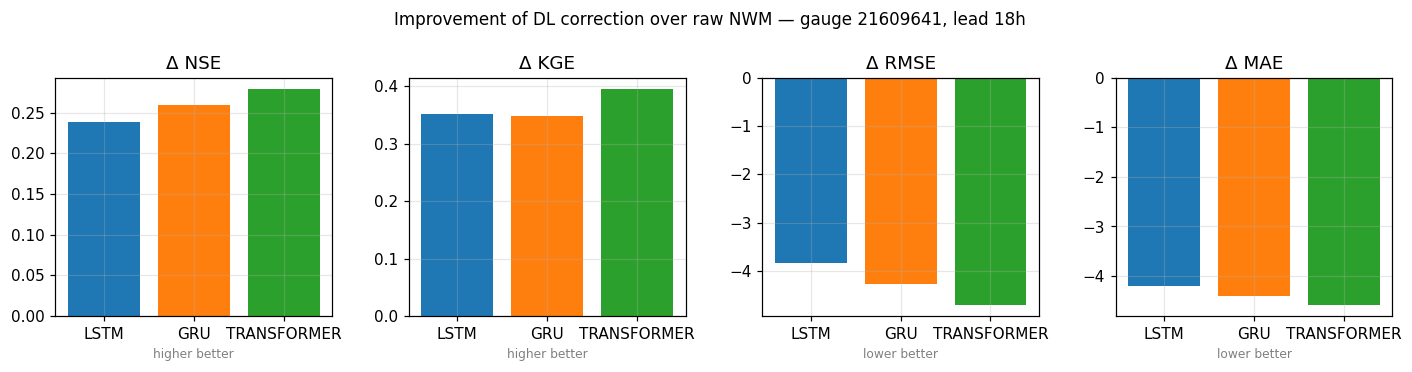

  → figures/task1_improvement_bars.png


In [19]:
LEAD = 18
GAUGE = "21609641"
metrics = []
for model in ["lstm", "gru", "transformer"]:
    run = t1_runs.get((GAUGE, LEAD, model))
    if run is None:
        continue
    with open(run / "summary.json") as f:
        s = json.load(f)
    nwm_m = s["metrics_nwm_baseline"]
    dl_m = s["metrics_dl_corrected"]
    metrics.append({
        "model": model.upper(),
        "Δ NSE":  dl_m["nse"]  - nwm_m["nse"],
        "Δ KGE":  dl_m["kge"]  - nwm_m["kge"],
        "Δ RMSE": dl_m["rmse"] - nwm_m["rmse"],
        "Δ MAE":  dl_m["mae"]  - nwm_m["mae"],
    })

if metrics:
    dfm = pd.DataFrame(metrics)
    fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
    bar_metrics = ["Δ NSE", "Δ KGE", "Δ RMSE", "Δ MAE"]
    colors = ["C0", "C1", "C2"]
    for ax, m in zip(axes, bar_metrics):
        bars = ax.bar(dfm["model"], dfm[m], color=colors)
        ax.axhline(0, color="k", lw=0.5)
        ax.set_title(m)
        # Direction hint
        better = "higher better" if m in ("Δ NSE", "Δ KGE") else "lower better"
        ax.set_xlabel(better, fontsize=8, color="gray")
    fig.suptitle(f"Improvement of DL correction over raw NWM — gauge {GAUGE}, lead {LEAD}h",
                 fontsize=11)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "task1_improvement_bars.png", bbox_inches="tight")
    plt.show()
    print("  → figures/task1_improvement_bars.png")
else:
    print("No matching runs found.")

---
# Task 2 figures

## Figure 6 — Training curves for the three CV models

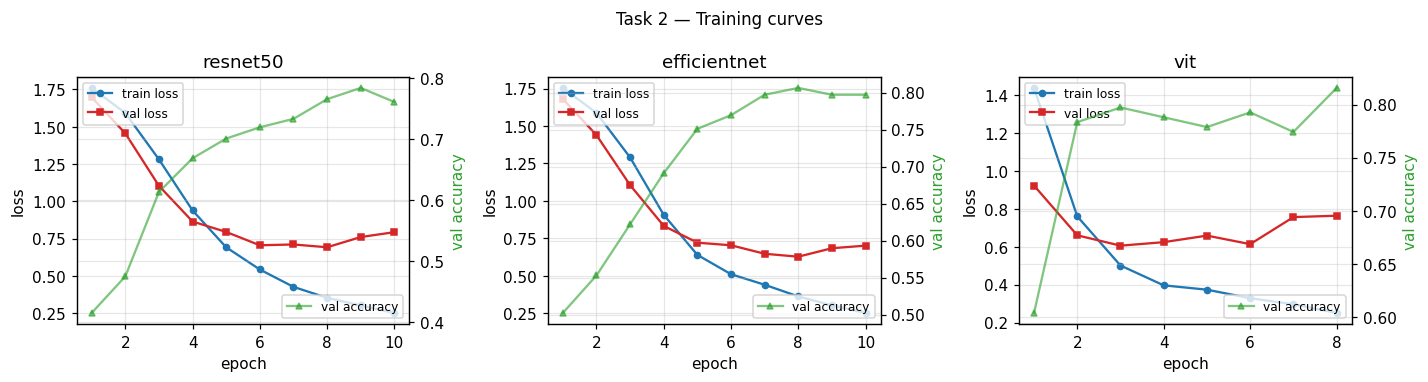

  → figures/task2_training_curves.png


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for ax, model in zip(axes, ["resnet50", "efficientnet", "vit"]):
    run = t2_runs.get(model)
    if run is None:
        ax.text(0.5, 0.5, f"no run for {model}", ha="center",
                va="center", transform=ax.transAxes)
        ax.set_title(model)
        continue
    h = pd.read_csv(run / "history.csv")
    ax2 = ax.twinx()
    ax.plot(h["epoch"], h["train_loss"], "C0-o", markersize=4, label="train loss")
    ax.plot(h["epoch"], h["val_loss"],   "C3-s", markersize=4, label="val loss")
    ax2.plot(h["epoch"], h["val_acc"], "C2-^", markersize=4, alpha=0.6, label="val accuracy")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax2.set_ylabel("val accuracy", color="C2")
    ax.set_title(model)
    ax.legend(loc="upper left", fontsize=8)
    ax2.legend(loc="lower right", fontsize=8)

fig.suptitle("Task 2 — Training curves", fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / "task2_training_curves.png", bbox_inches="tight")
plt.show()
print("  → figures/task2_training_curves.png")

## Figure 7 — Confusion matrices (one per model)

Damage levels 0 (no damage) through 5 (destroyed) on both axes. Diagonal
is correct predictions. Off-diagonal cells next to the diagonal are
"close" predictions (within ±1 level), which the reference paper notes
are operationally useful even when not exactly right.

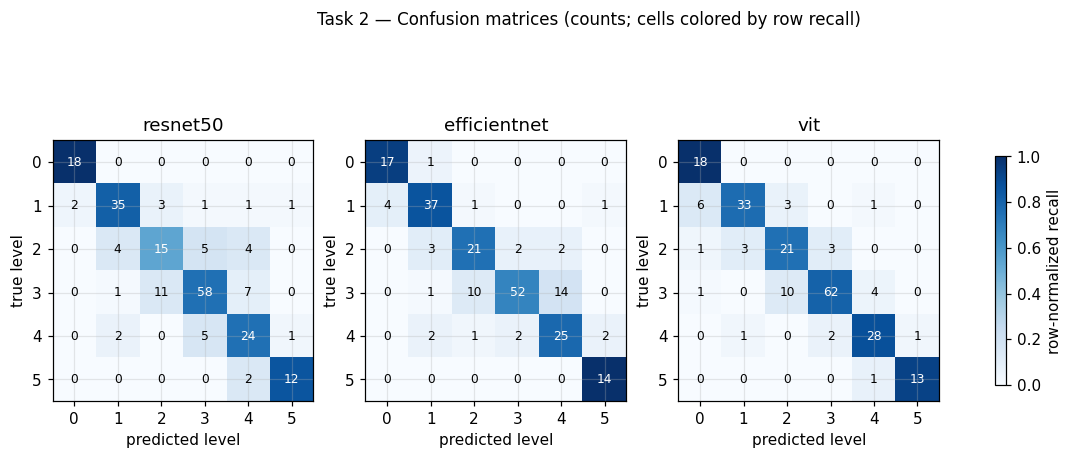

  → figures/task2_confusion_matrices.png


In [21]:
import numpy as np

N_CLASSES = 6
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))

for ax, model in zip(axes, ["resnet50", "efficientnet", "vit"]):
    run = t2_runs.get(model)
    if run is None:
        ax.text(0.5, 0.5, f"no run for {model}", ha="center",
                va="center", transform=ax.transAxes)
        ax.set_title(model)
        continue
    df = pd.read_csv(run / "test_predictions.csv")
    cm = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
    for t, p in zip(df["y_true"], df["y_pred"]):
        if 0 <= int(t) < N_CLASSES and 0 <= int(p) < N_CLASSES:
            cm[int(t), int(p)] += 1
    # Row-normalize so values are recall per class
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    last_im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            txt_color = "white" if cm_norm[i, j] > 0.5 else "black"
            ax.text(j, i, f"{cm[i,j]}", ha="center", va="center",
                    color=txt_color, fontsize=8)
    ax.set_xlabel("predicted level")
    ax.set_ylabel("true level")
    ax.set_xticks(range(N_CLASSES))
    ax.set_yticks(range(N_CLASSES))
    ax.set_title(model)

try:
    fig.colorbar(last_im, ax=axes.ravel().tolist(), shrink=0.6, label="row-normalized recall")
except NameError:
    pass  # no successful runs, skip colorbar
fig.suptitle("Task 2 — Confusion matrices (counts; cells colored by row recall)",
             fontsize=11, y=1.02)
plt.savefig(FIG_DIR / "task2_confusion_matrices.png", bbox_inches="tight")
plt.show()
print("  → figures/task2_confusion_matrices.png")

## Figure 8 — Per-class accuracy across models

Side-by-side bars showing each model's recall on each damage level.
Reveals which classes are systematically harder and whether different
architectures help with different classes.

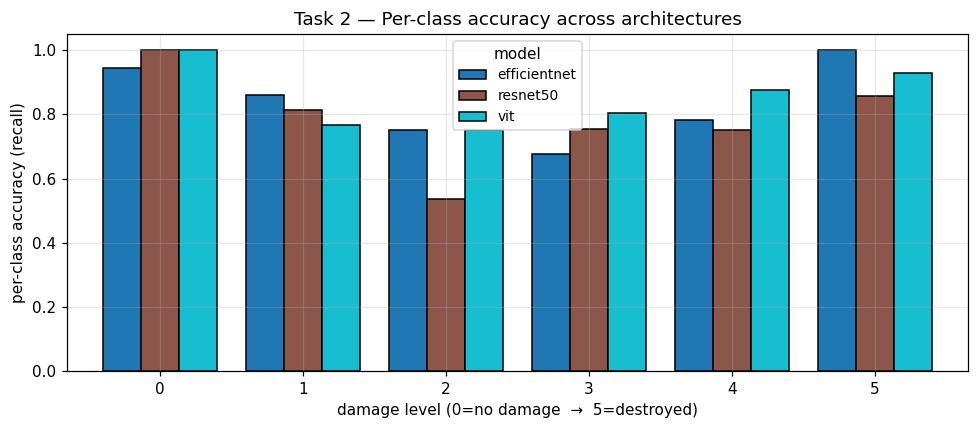

  → figures/task2_per_class_acc.png


In [22]:
records = []
for model in ["resnet50", "efficientnet", "vit"]:
    run = t2_runs.get(model)
    if run is None:
        continue
    with open(run / "summary.json") as f:
        s = json.load(f)
    pca = s.get("test_metrics", {}).get("per_class_acc", {})
    for level_str, acc in pca.items():
        records.append({"model": model, "level": int(level_str), "acc": float(acc)})

if records:
    dfp = pd.DataFrame(records)
    pivot = dfp.pivot(index="level", columns="model", values="acc")
    fig, ax = plt.subplots(figsize=(9, 4))
    pivot.plot(kind="bar", ax=ax, colormap="tab10", edgecolor="black", width=0.8)
    ax.set_xlabel("damage level (0=no damage  →  5=destroyed)")
    ax.set_ylabel("per-class accuracy (recall)")
    ax.set_ylim(0, 1.05)
    ax.set_xticklabels(range(6), rotation=0)
    ax.legend(title="model", fontsize=9)
    ax.set_title("Task 2 — Per-class accuracy across architectures")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "task2_per_class_acc.png", bbox_inches="tight")
    plt.show()
    print("  → figures/task2_per_class_acc.png")
else:
    print("No Task 2 runs found.")

---
# Summary

If everything ran, you should now have these files in `figures/`:

- `task1_training_curves.png`
- `task1_hydrograph.png`
- `task1_nse_vs_lead.png`
- `task1_pred_vs_obs.png`
- `task1_improvement_bars.png`
- `task2_training_curves.png`
- `task2_confusion_matrices.png`
- `task2_per_class_acc.png`

These are ready to drop into the report and presentation.

In [24]:
import os
print("Files in figures/:")
for f in sorted(FIG_DIR.glob("*.png")):
    size = f.stat().st_size / 1024
    print(f"  {f.name}  ({size:.0f} KB)")

Files in figures/:
  task1_hydrograph.png  (268 KB)
  task1_improvement_bars.png  (64 KB)
  task1_nse_vs_lead.png  (168 KB)
  task1_pred_vs_obs.png  (188 KB)
  task1_training_curves.png  (113 KB)
  task2_confusion_matrices.png  (86 KB)
  task2_per_class_acc.png  (58 KB)
  task2_training_curves.png  (181 KB)
